# 05 - Quantify latent complexity for matched normal–tumor comparisons

This notebook quantifies within-group latent geometry for matched normal–tumor comparisons.

It performs five tasks:

1. Loads latent coordinates generated by the trained VAE using the shared config loader
2. Loads aligned metadata from the preprocessing pipeline using the shared config loader
3. Constructs a comparison-ready working table using centralized labels and abbreviations
4. Computes latent geometry metrics separately for each normal and tumor group
5. Saves derived tables and summary plots for downstream reporting

The unit of analysis in this notebook is the matched comparison, such as `BLAD/TCC` or `Brain/GBM`, not the individual cancer label alone.

**Maintenance note:** comparison labels and plot abbreviations now live in `00_latent_space_config.ipynb`. Do not redefine them in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


In [2]:
# Shared Python-side configuration for latent-space notebooks.
# This config is expected to define COMPARISON_MAP, PLOT_LABEL_MAP,
# build_latent_dataframe(), add_standard_latent_labels(),
# build_latent_working_table(), and notebook-specific output directories.
%run ./00_latent_space_config.ipynb

required_config_objects = [
    "COMPARISON_MAP",
    "PLOT_LABEL_MAP",
    "build_latent_dataframe",
    "add_standard_latent_labels",
    "build_latent_working_table",
    "latent_columns",
    "NB05_PLOTS_DIR",
    "NB05_TABLES_DIR",
]

missing_config_objects = [name for name in required_config_objects if name not in globals()]
if missing_config_objects:
    raise RuntimeError(
        "The shared config notebook is missing required Notebook 5 objects: "
        f"{missing_config_objects}. Use the standardized 00_latent_space_config.ipynb "
        "created during the Notebook 4 standardization step."
    )


Notebook directory : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\notebooks
Project directory  : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity
ML input directory : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed\ml_inputs
Processed directory: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed
Output directory   : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\global_cancer
Expression path: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed\ml_inputs\hu35ksuba_expr_top3000_variance.csv | exists: True
Metadata path  : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\p

In [3]:
# ------------------------------------------------------------------
# Load latent coordinates + metadata using the shared config helpers
# ------------------------------------------------------------------
df = build_latent_dataframe(
    latent_path=LATENT_PATH,
    metadata_path=METADATA_ALIGNED_PATH,
    require_full_contract=True,
)

df = add_standard_latent_labels(df)
report_unmapped_latent_labels(df)

work = build_latent_working_table(df)
latent_cols = latent_columns(work)

# Keep sample_id explicit in saved tables while preserving index alignment.
if "sample_id" not in work.columns:
    work.insert(0, "sample_id", work.index.astype(str))

print("latent path   :", LATENT_PATH)
print("metadata path :", METADATA_ALIGNED_PATH)
print("df shape      :", df.shape)
print("work shape    :", work.shape)
print("latent dims   :", len(latent_cols))


latent path   : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed\latent.npy
metadata path : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed\metadata_aligned.csv
latent shape  : (278, 10)
metadata shape: (278, 43)
df shape      : (278, 53)


In [4]:
# ------------------------------------------------------------------
# Comparison definitions from centralized config
# ------------------------------------------------------------------
# In config, COMPARISON_MAP is keyed as:
#   (normal_tissue, tumor_disease) -> canonical comparison label
# For metric computation here, invert it to:
#   canonical comparison label -> (normal_tissue, tumor_disease)
comparison_map = {
    comparison: tissue_disease
    for tissue_disease, comparison in COMPARISON_MAP.items()
}

comparison_order = list(PLOT_LABEL_MAP.keys())
comparison_map = {
    comparison: comparison_map[comparison]
    for comparison in comparison_order
    if comparison in comparison_map
}

latent_with_meta = work.copy()

print("Configured comparisons:", len(comparison_map))
print("Tumor labels represented in current latent table:", latent_with_meta["short_label"].dropna().nunique())
print("Rows without tumor comparison label:", latent_with_meta["short_label"].isna().sum())

display(
    pd.DataFrame(
        [
            {
                "comparison": comp,
                "plot_label": PLOT_LABEL_MAP.get(comp),
                "normal_tissue": normal_tissue,
                "tumor_disease": tumor_disease,
            }
            for comp, (normal_tissue, tumor_disease) in comparison_map.items()
        ]
    )
)


latent_with_meta shape: (278, 19)
Matched comparison labels: 16
Unlabeled rows: 33


In [5]:
# ------------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------------
def safe_cov(X: np.ndarray) -> np.ndarray:
    if X.ndim != 2:
        raise ValueError("X must be 2-dimensional.")
    if X.shape[0] < 2:
        return np.full((X.shape[1], X.shape[1]), np.nan)
    return np.cov(X, rowvar=False)

def eigvals_sorted(cov: np.ndarray) -> np.ndarray:
    if np.isnan(cov).all():
        return np.array([np.nan])
    vals = np.linalg.eigvalsh(cov)
    vals = np.clip(vals, 0, None)
    return np.sort(vals)[::-1]

def participation_ratio(eigs: np.ndarray) -> float:
    if np.isnan(eigs).all():
        return np.nan
    s1 = np.sum(eigs)
    s2 = np.sum(eigs**2)
    if s2 <= 0:
        return np.nan
    return float((s1**2) / s2)

def eig_entropy(eigs: np.ndarray) -> float:
    if np.isnan(eigs).all():
        return np.nan
    total = np.sum(eigs)
    if total <= 0:
        return np.nan
    p = eigs / total
    p = p[p > 0]
    if len(p) == 0:
        return np.nan
    return float(-(p * np.log(p)).sum())

def top_eig_fraction(eigs: np.ndarray) -> float:
    if np.isnan(eigs).all():
        return np.nan
    total = np.sum(eigs)
    if total <= 0:
        return np.nan
    return float(eigs[0] / total)

def centroid_distances(X: np.ndarray) -> np.ndarray:
    if X.ndim != 2:
        raise ValueError("X must be 2-dimensional.")
    if X.shape[0] == 0:
        return np.array([np.nan])
    c = X.mean(axis=0)
    return np.linalg.norm(X - c, axis=1)


In [6]:
# ------------------------------------------------------------------
# Compute one row per matched comparison
# ------------------------------------------------------------------
results = []

for comp, (normal_tissue, tumor_disease) in comparison_map.items():
    df_normal = work.loc[
        (work["state"] == "normal") &
        (work["tissue"] == normal_tissue)
    ]
    df_tumor = work.loc[
        (work["state"] == "cancer") &
        (work["tissue"] == normal_tissue) &
        (work["disease"] == tumor_disease)
    ]

    n_normal = len(df_normal)
    n_tumor = len(df_tumor)

    if n_normal < 2 or n_tumor < 2:
        print(f"Skipping {comp}: n_normal={n_normal}, n_tumor={n_tumor}")
        continue

    X_normal = df_normal[latent_cols].to_numpy(dtype=float)
    X_tumor = df_tumor[latent_cols].to_numpy(dtype=float)

    cov_normal = safe_cov(X_normal)
    cov_tumor = safe_cov(X_tumor)

    eigs_normal = eigvals_sorted(cov_normal)
    eigs_tumor = eigvals_sorted(cov_tumor)

    pr_normal = participation_ratio(eigs_normal)
    pr_tumor = participation_ratio(eigs_tumor)

    ent_normal = eig_entropy(eigs_normal)
    ent_tumor = eig_entropy(eigs_tumor)

    anisotropy_normal = top_eig_fraction(eigs_normal)
    anisotropy_tumor = top_eig_fraction(eigs_tumor)

    radius_normal = float(np.nanmean(centroid_distances(X_normal)))
    radius_tumor = float(np.nanmean(centroid_distances(X_tumor)))

    centroid_normal = X_normal.mean(axis=0)
    centroid_tumor = X_tumor.mean(axis=0)
    centroid_distance = float(np.linalg.norm(centroid_tumor - centroid_normal))

    results.append(
        {
            "comparison": comp,
            "normal_tissue": normal_tissue,
            "tumor_disease": tumor_disease,
            "n_normal": n_normal,
            "n_tumor": n_tumor,
            "pr_normal": pr_normal,
            "pr_tumor": pr_tumor,
            "pr_delta": pr_tumor - pr_normal,
            "eig_entropy_normal": ent_normal,
            "eig_entropy_tumor": ent_tumor,
            "eig_entropy_delta": ent_tumor - ent_normal,
            "anisotropy_normal": anisotropy_normal,
            "anisotropy_tumor": anisotropy_tumor,
            "anisotropy_delta": anisotropy_tumor - anisotropy_normal,
            "radius_normal": radius_normal,
            "radius_tumor": radius_tumor,
            "radius_delta": radius_tumor - radius_normal,
            "centroid_distance": centroid_distance,
            "plot_label": PLOT_LABEL_MAP.get(comp, comp),
        }
    )

latent_comparison_df = (
    pd.DataFrame(results)
    .sort_values("comparison")
    .reset_index(drop=True)
)

latent_comparison_df["normal_code"] = latent_comparison_df["comparison"].str.split("/").str[0]
latent_comparison_df["tumor_code"] = latent_comparison_df["comparison"].str.split("/").str[1]

print("latent_comparison_df shape:", latent_comparison_df.shape)
display(latent_comparison_df)

Skipping PB/AML: n_normal=5, n_tumor=0
Skipping PB/B-ALL: n_normal=0, n_tumor=10
Skipping PB/T-ALL: n_normal=0, n_tumor=10
latent_comparison_df shape: (13, 20)


,comparison,normal_tissue,tumor_disease,n_normal,n_tumor,pr_normal,pr_tumor,pr_delta,eig_entropy_normal,eig_entropy_tumor,eig_entropy_delta,anisotropy_normal,anisotropy_tumor,anisotropy_delta,radius_normal,radius_tumor,radius_delta,centroid_distance,normal_code,tumor_code
0,BLAD/TCC,Bladder,bladder transitional cell carcinoma,7,10,2.868039,2.900468,0.032430,1.210105,1.301600,0.091495,0.485303,0.510975,0.025673,20.936583,18.738992,-2.197592,38.866351,BLAD,TCC
1,BR/BRAD,Breast,breast adenocarcinoma,5,11,1.653903,2.879065,1.225162,0.654532,1.318833,0.664301,0.740404,0.511646,-0.228758,25.817442,30.178578,4.361136,35.517579,BR,BRAD
2,Brain/GBM,Brain,glioblastoma,8,10,2.591654,3.901760,1.310106,1.140887,1.578678,0.437790,0.539627,0.375599,-0.164028,17.914772,22.012531,4.097759,26.573303,Brain,GBM
3,Brain/MB,Brain,medulloblastoma,8,10,2.591654,3.435262,0.843608,1.140887,1.428463,0.287576,0.539627,0.403017,-0.136610,17.914772,19.155003,1.240231,33.630825,Brain,MB
4,COL/COADREAD,Colon,colorectal adenocarcinoma,11,11,2.534254,2.814696,0.280442,1.151971,1.352936,0.200965,0.546291,0.540648,-0.005643,19.358334,27.708412,8.350078,25.237612,COL,COADREAD
5,GC/FL,Lymphoid Tissue,Follicular lymphoma,6,10,1.385258,3.388569,2.003311,0.553617,1.434962,0.881346,0.840209,0.433634,-0.406575,17.687778,16.790574,-0.897204,28.379365,GC,FL
6,GC/LBCL,Lymphoid Tissue,large B-cell lymphoma,6,10,1.385258,4.396195,3.010937,0.553617,1.648573,1.094957,0.840209,0.325393,-0.514816,17.687778,11.047483,-6.640295,25.546050,GC,LBCL
7,KID/RCC,Kidney,renal cell carcinoma,12,11,3.347660,3.133412,-0.214248,1.421542,1.356495,-0.065047,0.406812,0.450173,0.043361,16.744116,27.882033,11.137916,17.164091,KID,RCC
8,LU/LUAD,Lung,lung adenocarcinoma,7,11,1.931388,2.761039,0.829652,0.883787,1.319109,0.435322,0.677208,0.544148,-0.133060,21.418060,25.736663,4.318603,15.243725,LU,LUAD
9,OV/OVAD,Ovary,ovarian adenocarcinoma,4,11,2.162428,2.431250,0.268821,0.905705,1.199133,0.293428,0.614311,0.580747,-0.033564,14.984917,25.331491,10.346574,25.847101,OV,OVAD


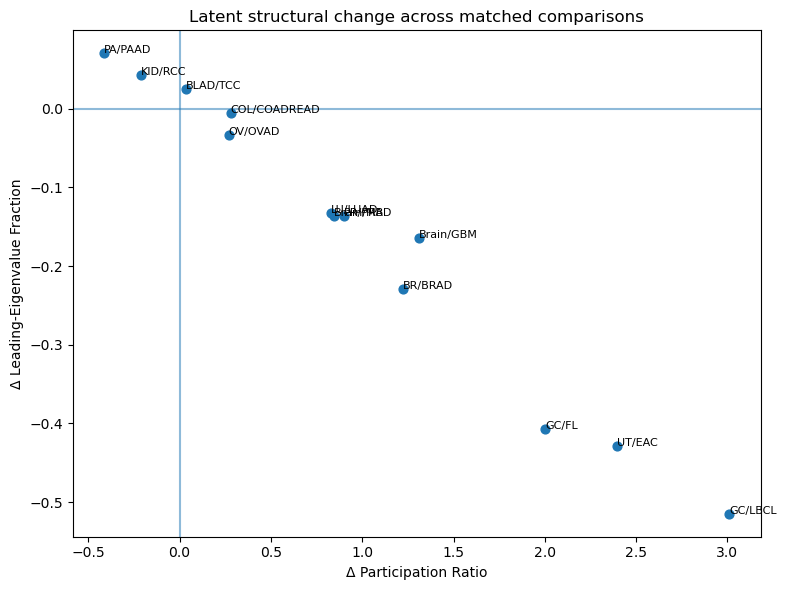

In [7]:
# ------------------------------------------------------------------
# Quick structural-change plot
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.axhline(0, alpha=0.5)
plt.axvline(0, alpha=0.5)

x = latent_comparison_df["pr_delta"]
y = latent_comparison_df["anisotropy_delta"]
labels = latent_comparison_df["plot_label"]

plt.scatter(x, y, s=40)

for xi, yi, lab in zip(x, y, labels):
    plt.text(xi, yi, lab, fontsize=8)

plt.xlabel("Δ Participation Ratio")
plt.ylabel("Δ Leading-Eigenvalue Fraction")
plt.title("Latent structural change across matched comparisons")
plt.tight_layout()

plot_path = NB05_PLOTS_DIR / "latent_structural_change_space.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved plot:", plot_path)


In [8]:
# ------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------
latent_with_meta.to_csv(NB05_TABLES_DIR / "latent_with_metadata.csv", index=False)
latent_comparison_df.to_csv(NB05_TABLES_DIR / "latent_comparison_metrics.csv", index=False)

# Optional compatibility copies for existing Quarto/reporting code that still
# expects the previous canonical parent directory. Remove these once downstream
# reports point to notebook-specific subdirectories.
latent_with_meta.to_csv(LATENT_TABLES_DIR / "latent_with_metadata.csv", index=False)
latent_comparison_df.to_csv(LATENT_TABLES_DIR / "latent_comparison_metrics.csv", index=False)

print("Saved Notebook 5 tables:")
print(" -", NB05_TABLES_DIR / "latent_with_metadata.csv")
print(" -", NB05_TABLES_DIR / "latent_comparison_metrics.csv")
print("Saved compatibility copies:")
print(" -", LATENT_TABLES_DIR / "latent_with_metadata.csv")
print(" -", LATENT_TABLES_DIR / "latent_comparison_metrics.csv")


Saved:
 - C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\global_cancer\tables\latent\latent_with_metadata.csv
 - C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\global_cancer\tables\latent\latent_comparison_metrics.csv
